# Temperature-dependent growth: the extended Ratkowsky Square Root model

Bacterial growth rate rises roughly as a square root of the distance from the minimum
growth temperature, then drops sharply near the maximum.  The *extended Ratkowsky*
Square Root model (Ratkowsky *et al.* 1983) captures both regimes with four parameters:

$$\sqrt{\mu} = b\,(T - T_{\min})\,\bigl[1 - e^{c(T - T_{\max})}\bigr]$$

where $\mu$ is the growth rate (h⁻¹), $T$ is temperature (°C), $T_{\min}$ and
$T_{\max}$ are the no-growth boundary temperatures, and $b$ and $c$ are
species-specific empirical constants.

This notebook demonstrates `multicellular`'s variable-growth-rate feature:
a large environment is divided into three temperature bands (cold / warm / hot),
each band seeded with a small cluster of cells.  Every cell carries a
`growth_rate_law` — a callable `(intracellular, extracellular) → μ` — that
evaluates the Ratkowsky model against the local `temperature` field at its
centroid.  `Colony.step` updates each cell's `growth_rate` before integrating
growth, so the cells respond dynamically to their local thermal environment.
Daughter cells inherit the law from their parent, so the coupling persists
across every generation.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image

from multicellular import Cell, Colony, Environment, Field, Simulation, visualize

os.makedirs("outputs", exist_ok=True)
plt.rcParams["figure.dpi"] = 100

# Extended Ratkowsky model parameters
T_MIN =  5.0   # °C   lower no-growth temperature
T_MAX = 45.0   # °C   upper no-growth temperature
b     =  0.03  # sqrt(h⁻¹) °C⁻¹
c     =  0.2   # °C⁻¹

# Three band temperatures (°C)
T_COLD, T_WARM, T_HOT = 15.0, 25.0, 37.0

## 1. Growth rate vs temperature: the Ratkowsky curve

The sub-optimal regime (left of the peak) is governed by Arrhenius-like
kinetics; the exponential correction term $[1 - e^{c(T-T_{\max})}]$ keeps
growth positive between $T_{\min}$ and $T_{\max}$ and drives it sharply
to zero as temperature approaches $T_{\max}$.  The three vertical dashed
lines mark the temperatures used in the simulation below.

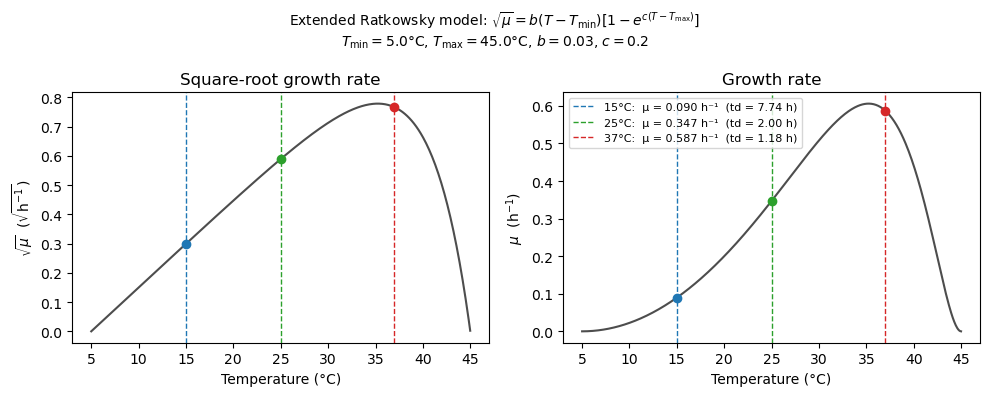

In [2]:
T_range = np.linspace(T_MIN + 0.01, T_MAX - 0.01, 500)
sqrt_mu = b * (T_range - T_MIN) * (1.0 - np.exp(c * (T_range - T_MAX)))
mu_curve = sqrt_mu ** 2

band_colors = {T_COLD: "tab:blue", T_WARM: "tab:green", T_HOT: "tab:red"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(T_range, sqrt_mu, color="0.3")
ax2.plot(T_range, mu_curve, color="0.3")

for T_band, color in band_colors.items():
    sm = b * (T_band - T_MIN) * (1.0 - np.exp(c * (T_band - T_MAX)))
    mu_band = sm ** 2
    ax1.axvline(T_band, color=color, linestyle="--", linewidth=1.0)
    ax1.scatter([T_band], [sm], color=color, zorder=5)
    ax2.axvline(T_band, color=color, linestyle="--", linewidth=1.0,
                label=f"{T_band:.0f}\u00b0C:  \u03bc = {mu_band:.3f} h\u207b\u00b9  (td = {np.log(2)/mu_band:.2f} h)")
    ax2.scatter([T_band], [mu_band], color=color, zorder=5)

ax1.set_xlabel("Temperature (\u00b0C)")
ax1.set_ylabel(r"$\sqrt{\mu}$  ($\sqrt{\mathrm{h}^{-1}}$)")
ax1.set_title("Square-root growth rate")

ax2.set_xlabel("Temperature (\u00b0C)")
ax2.set_ylabel(r"$\mu$  (h$^{-1}$)")
ax2.set_title("Growth rate")
ax2.legend(fontsize=8)

fig.suptitle(
    r"Extended Ratkowsky model: $\sqrt{\mu} = b(T-T_{\min})[1 - e^{c(T-T_{\max})}]$"
    f"\n$T_{{\\min}}={T_MIN}$°C, $T_{{\\max}}={T_MAX}$°C, $b={b}$, $c={c}$",
    fontsize=10,
)
fig.tight_layout()
plt.show()

## 2. Environment: three temperature bands

The environment is 150 × 60 μm, split into three equal 50 μm bands along x.
Temperature is stored as a `Field` with `is_chemical=True` so that
`Colony.apply_chemical_fields` injects the local value into every cell's
`concentrations` dict each step (under the key `"temperature"`).  The field
does not diffuse (`diffuses=False`), so the step function stays sharp
throughout the simulation.

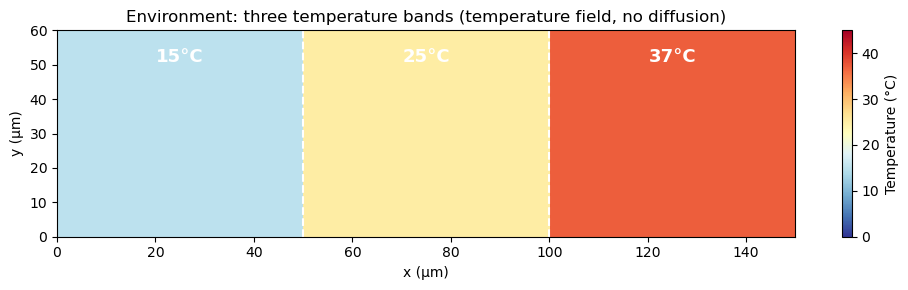

In [3]:
SHAPE  = (30, 75)       # 30 rows × 75 cols  →  2 μm per grid cell
BOUNDS = (150.0, 60.0)  # μm

temperature_values = np.zeros(SHAPE)
temperature_values[:, :25]  = T_COLD   # x ∈ [0,  50) μm
temperature_values[:, 25:50] = T_WARM  # x ∈ [50, 100) μm
temperature_values[:, 50:]   = T_HOT   # x ∈ [100,150) μm

env = Environment(
    "Three Temperature Bands",
    shape=SHAPE, bounds=BOUNDS,
    fields=[Field("temperature", temperature_values, is_chemical=True)],
)

fig, ax = plt.subplots(figsize=(10, 3))
im = ax.imshow(
    temperature_values, origin="lower",
    extent=[0, BOUNDS[0], 0, BOUNDS[1]],
    cmap="RdYlBu_r", vmin=0, vmax=T_MAX, aspect="auto",
)
fig.colorbar(im, ax=ax, label="Temperature (\u00b0C)")
for x_boundary in [50, 100]:
    ax.axvline(x_boundary, color="white", linewidth=1.5, linestyle="--")
ax.text(25,  55, f"{T_COLD:.0f}\u00b0C", ha="center", va="top", color="white",
        fontsize=13, fontweight="bold")
ax.text(75,  55, f"{T_WARM:.0f}\u00b0C", ha="center", va="top", color="white",
        fontsize=13, fontweight="bold")
ax.text(125, 55, f"{T_HOT:.0f}\u00b0C",  ha="center", va="top", color="white",
        fontsize=13, fontweight="bold")
ax.set_xlabel("x (\u03bcm)")
ax.set_ylabel("y (\u03bcm)")
ax.set_title("Environment: three temperature bands (temperature field, no diffusion)")
fig.tight_layout()
plt.show()

## 3. Connecting temperature to growth: the `growth_rate_law`

`growth_rate_law` is an optional attribute on `Cell`: a callable
`(intracellular: dict, extracellular: dict) → float` that returns the new
growth rate.  `Colony.step` calls it once per living cell per step,
passing the cell's own concentration dict and a dict of all field values
at the cell's centroid, then writes the result back to `cell.growth_rate`.
Daughter cells inherit the callable unchanged.

Here the extracellular dict will always contain `"temperature"` (injected
by `apply_chemical_fields` before the growth-rate update), so the Ratkowsky
model can read it directly.

In [4]:
def ratkowsky(intracellular, extracellular):
    """Extended Ratkowsky Square Root model."""
    T = extracellular.get("temperature", T_MIN)
    if T <= T_MIN or T >= T_MAX:
        return 0.0
    sqrt_mu = b * (T - T_MIN) * (1.0 - np.exp(c * (T - T_MAX)))
    return max(0.0, sqrt_mu ** 2)


# Preview the growth rates and doubling times for the three bands
for T_band, label in [(T_COLD, "cold"), (T_WARM, "warm"), (T_HOT, "hot")]:
    mu = ratkowsky({}, {"temperature": T_band})
    print(f"{label:4s}  T = {T_band:.0f}\u00b0C   \u03bc = {mu:.4f} h\u207b\u00b9   "
          f"doubling time = {np.log(2) / mu:.2f} h")

cold  T = 15°C   μ = 0.0896 h⁻¹   doubling time = 7.74 h
warm  T = 25°C   μ = 0.3469 h⁻¹   doubling time = 2.00 h
hot   T = 37°C   μ = 0.5870 h⁻¹   doubling time = 1.18 h


## 4. Colony simulation

Two cells are placed in each temperature band, oriented randomly.  Each
cell is given the `ratkowsky` callable as its `growth_rate_law` and an
initial `growth_rate` equal to the Ratkowsky prediction for its band's
temperature.  `Colony.step` will update `growth_rate` from the law on
every subsequent step, so the initial value only matters for the very first
integration sub-step.

In [5]:
rng = np.random.default_rng(0)

# (band_label, temperature, seed_positions)
band_specs = [
    ("cold", T_COLD, [[23.0, 28.0], [27.0, 32.0]]),
    ("warm", T_WARM, [[73.0, 28.0], [77.0, 32.0]]),
    ("hot",  T_HOT,  [[123.0, 28.0], [127.0, 32.0]]),
]

cells = []
for band_idx, (band_name, T_band, positions) in enumerate(band_specs):
    mu0 = ratkowsky({}, {"temperature": T_band})
    for j, pos in enumerate(positions):
        angle = rng.uniform(0, 2 * np.pi)
        cell = Cell(
            id=len(cells),
            position=pos,
            orientation=[np.cos(angle), np.sin(angle)],
            length=2.0,
            growth_rate=mu0,
            growth_rate_law=ratkowsky,
            rng=np.random.default_rng(band_idx * 10 + j),
        )
        cells.append(cell)

colony = Colony(cells, env, k=10.0, drag=1.0)
sim    = Simulation(colony, dt=0.05, t_max=6.0)
df     = sim.run()

t_final = df["time"].max()
n_final = int(df[df["time"] == t_final]["alive"].sum())
print(f"\n{n_final} living cells at t = {t_final:.1f} h")

100%|██████████| 120/120 [00:01<00:00, 93.79it/s]



100 living cells at t = 6.0 h


## 5. Diverging colony sizes

Cells in each band are identified by their x-position.  Colony size in each
band grows roughly exponentially at the Ratkowsky rate for that temperature;
the dashed curves show the theoretical prediction $n(t) = n_0\,e^{\mu t}$
with $n_0 = 2$ for reference.  The divergence between bands is already
stark after a few hours.

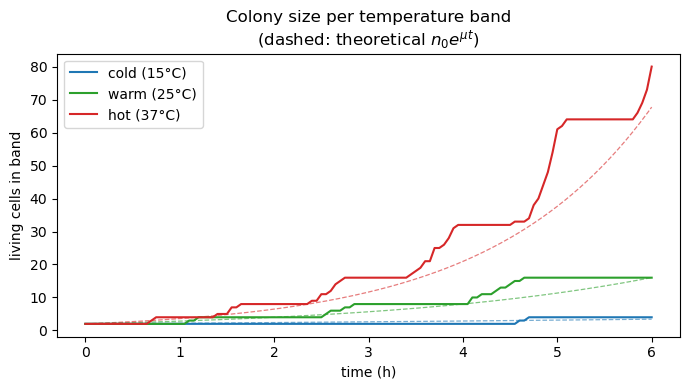

In [6]:
df_alive = df[df["alive"]].copy()
df_alive["band"] = pd.cut(
    df_alive["position_x"],
    bins=[0, 50, 100, 150],
    labels=[f"cold ({T_COLD:.0f}\u00b0C)", f"warm ({T_WARM:.0f}\u00b0C)", f"hot ({T_HOT:.0f}\u00b0C)"],
)

band_counts = (
    df_alive.groupby(["time", "band"], observed=True)["cell_id"]
    .nunique()
    .reset_index()
    .rename(columns={"cell_id": "n_cells"})
)

palette = {
    f"cold ({T_COLD:.0f}\u00b0C)": "tab:blue",
    f"warm ({T_WARM:.0f}\u00b0C)": "tab:green",
    f"hot ({T_HOT:.0f}\u00b0C)": "tab:red",
}

fig, ax = plt.subplots(figsize=(7, 4))
t_theory = np.linspace(0, 6.0, 300)
n0 = 2

for T_band, label_key in [
    (T_COLD, f"cold ({T_COLD:.0f}\u00b0C)"),
    (T_WARM, f"warm ({T_WARM:.0f}\u00b0C)"),
    (T_HOT,  f"hot ({T_HOT:.0f}\u00b0C)"),
]:
    mu = ratkowsky({}, {"temperature": T_band})
    color = palette[label_key]
    ax.plot(t_theory, n0 * np.exp(mu * t_theory), "--", color=color,
            linewidth=0.9, alpha=0.6)

for band_label, group in band_counts.groupby("band", observed=True):
    color = palette.get(str(band_label), "gray")
    ax.plot(group["time"], group["n_cells"], color=color, label=str(band_label))

ax.set_xlabel("time (h)")
ax.set_ylabel("living cells in band")
ax.set_title(
    "Colony size per temperature band\n"
    "(dashed: theoretical $n_0 e^{\\mu t}$)"
)
ax.legend()
fig.tight_layout()
plt.show()

## 6. Colony animation

Cells are colored by their local `temperature` field value (red channel,
normalized by the peak field value of 37°C), so cold cells appear dark and
hot cells appear bright red.  The most striking feature is structural: the
hot-band cluster (right) fills its lane while the cold-band cluster (left)
barely doubles over the same interval.

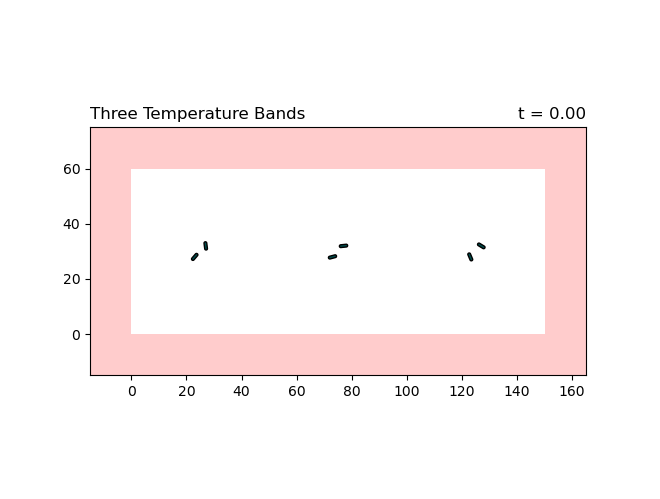

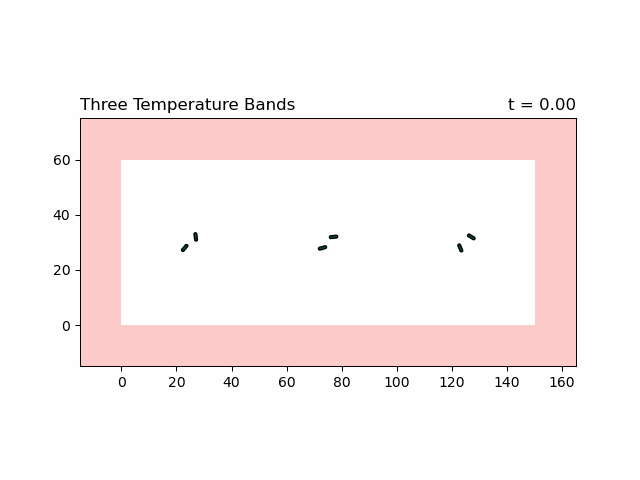

In [7]:
visualize(
    sim, red="temperature", stride=2, interval=80,
    save_path="outputs", filename="ratkowsky_growth.gif", show_progress=False,
)
Image(filename="outputs/ratkowsky_growth.gif")